In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

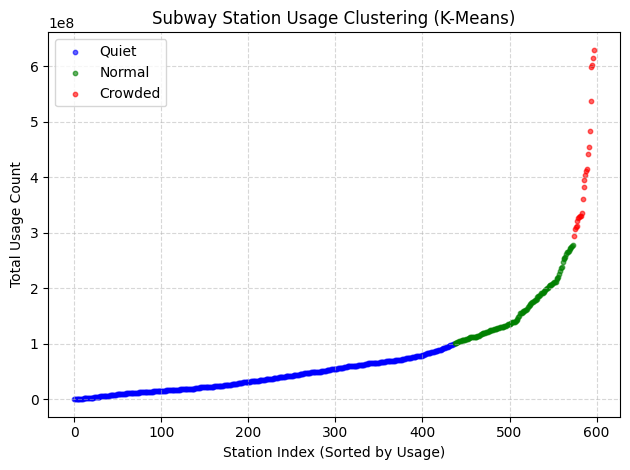

In [11]:
# 데이터 로드 및 전처리
df = pd.read_csv(r"C:\Users\soldesk\Documents\GitHub\MS_SAY_EJP\subway.csv", header=None)
df.columns = ['연도', '월', '일', '노선', '역명', '승차', '하차']
df['total'] = df['승차'] + df['하차']
station_usage = df.groupby('역명')['total'].sum().reset_index()

# KMeans 군집화 (K=3)
X = station_usage[['total']].values
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
station_usage['cluster'] = kmeans.fit_predict(X)

# 중심값 기준 레이블 매핑 (한적, 일반, 혼잡)
centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)
label_map = {sorted_idx[0]: 'Quiet', sorted_idx[1]: 'Normal', sorted_idx[2]: 'Crowded'}
station_usage['Status'] = station_usage['cluster'].map(label_map)

# 시각화를 위한 정렬
station_usage = station_usage.sort_values('total').reset_index(drop=True)

# 산점도 그리기
colors = {'Quiet': 'blue', 'Normal': 'green', 'Crowded': 'red'}
for status in ['Quiet', 'Normal', 'Crowded']:
    mask = station_usage['Status'] == status
    plt.scatter(station_usage.index[mask], station_usage['total'][mask], 
                c=colors[status], label=status, s=10, alpha=0.6)

plt.xlabel('Station Index (Sorted by Usage)')
plt.ylabel('Total Usage Count')
plt.title('Subway Station Usage Clustering (K-Means)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('subway_clustering_scatter.png')

In [ ]:
import pandas as pd
import numpy as np

# 1. 역명 입력 시 혼잡도 산정 결과 출력 함수
def get_info_by_station(station_name):
    # station_usage 데이터프레임에서 해당 역명 검색
    result = station_usage[station_usage['역명'] == station_name]
    if not result.empty:
        status = result.iloc[0]['Status']
        usage = result.iloc[0]['total']
        return f"역명: {station_name} | 누적 승하차 수: {usage:,} | 결과: {status}"
    else:
        return f"'{station_name}'은(는) 데이터에 존재하지 않는 역명입니다."

# 2. 승하차 수 입력 시 속할 그룹 출력 함수
def get_info_by_usage(usage_value):
    # 학습된 kmeans 모델로 클러스터 번호 예측
    cluster_idx = kmeans.predict([[usage_value]])[0]
    # 번호를 '한적/일반/혼잡' 레이블로 변환
    status = label_map[cluster_idx]
    return f"승하차 수가 {usage_value:,}일 경우 예측 그룹: {status}"

# 실행 예시
print(get_info_by_station("종각"))

print(get_info_by_usage(10000000))
# 출력: 승하차 수: 10,000,000 | 예측 그룹: 한적

역명: 종각 | 누적 승하차 수: 275,295,720 | 결과: Normal
입력 승하차 수: 10,000,000 | 예측 그룹: Quiet
